[문제]
광고 예산(TV, Radio, Newspaper)과 판매량(Sales) 데이터를 사용하여 선형 회귀 모델을 학습시키고, 새로운 광고 예산이 주어졌을 때 판매량을 예측하는 프로그램을 작성하세요. 또한, 예측 결과와 실제 데이터를 시각화하여 모델의 성능을 직관적으로 확인하세요.

[세부 요구사항]
1. 데이터 로드
 - 캐글(https://www.kaggle.com/)에서 구글 계정으로 가입합니다.
 - 캐글 메인에서 좌측 Datasets 메뉴 선택하고, 다음 화면 상단 검색창에서 Advertising을 검색합니다.
 - 다음 화면에서 상단 Datasets를 클릭하고 조회된 결과에서 Advertising Dataset 선택한 후 Download 버튼 클릭하여 다운받습니다.
 - 다운받은 파일은 로컬 PC dataset로 이동하여 저장합니다.
 - dataset/Advertising.csv 경로에서 데이터를 로드합니다. (pandas 라이브러리 사용)

2. 데이터 전처리
 - 불필요한 'Unnamed: 0' 컬럼을 제거합니다.
 - 독립 변수(X)는 'TV', 'Radio', 'Newspaper' 컬럼으로 설정합니다.
 - 종속 변수(y)는 'Sales' 컬럼으로 설정합니다.

3. 데이터 분할
 - 전체 데이터를 학습 데이터와 테스트 데이터로 8:2 비율로 분할합니다. (scikit-learn의 train_test_split 함수 사용)

4. 모델 학습
선형 회귀 모델을 학습 데이터로 학습시킵니다. (scikit-learn의 LinearRegression 모델 사용)

5. 예측
 - 테스트 데이터에 대한 판매량을 예측합니다.

6. 모델 평가
 - 테스트 데이터에 대한 R-squared (결정 계수) 값을 계산하여 모델 성능을 평가합니다. (scikit-learn의 r2_score 함수 사용)

7. 새로운 데이터 예측
 - TV=200, Radio=50, Newspaper=30 일 때 판매량을 예측합니다.

8. 결과 출력
 - 테스트 데이터에 대한 R-squared 값을 출력합니다.
 - 새로운 데이터에 대한 예측 판매량을 출력합니다.

9. 시각화
 - 실제 판매량 vs 예측 판매량 산점도: 테스트 데이터의 실제 판매량과 예측 판매량을 산점도로 시각화합니다. x축은 실제 판매량, y축은 예측 판매량으로 설정하고, 제목과 축 레이블을 명확하게 표시합니다.
 - 각 독립변수와 판매량과의 관계 시각화: 각 독립 변수('TV', 'Radio', 'Newspaper')와 'Sales' 간의 산점도를 그리고, 회귀선을 추가하여 시각화합니다.

데이터 전처리
 - 불필요한 'Unnamed: 0' 컬럼을 제거합니다.
 - 독립 변수(X)는 'TV', 'Radio', 'Newspaper' 컬럼으로 설정합니다.
 - 종속 변수(y)는 'Sales' 컬럼으로 설정합니다.

In [1]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns 
# 1. 현재 주피터 노트북의 실행 위치 확인
print(f"현재 위치: {os.getcwd()}")

# 2. 현재 폴더에 무엇이 있는지 확인
print(f"현재 폴더 내용: {os.listdir('.')}")

# 3. 상위 폴더나 하위 폴더에 raw_ml이 있는지 확인
possible_paths = [
    'dataset/Advertising.csv',
]

for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ 파일을 찾았습니다! 사용할 경로: {path}")
        break
else:
    print("❌ 파일을 찾지 못했습니다. 폴더 구조를 다시 확인해야 합니다.")

현재 위치: c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\colab
현재 폴더 내용: ['advertising-dataset.ipynb', 'dataset', 'ml.ipynb', 'pythonFunction01.ipynb', 'requirements.txt', '민예린_0330_kaggle_Advertising_linear_model.ipynb']
✅ 파일을 찾았습니다! 사용할 경로: dataset/Advertising.csv


In [2]:
df = pd.read_csv('dataset/Advertising.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
from itables import show
show(df)

Loading ITables v2.7.3 from the internet... (need help?)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


 독립 변수(X)는 'TV', 'Radio', 'Newspaper' 컬럼으로 설정합니다.
 - 종속 변수(y)는 'Sales' 컬럼으로 설정합니다.



In [5]:
df=df.drop(columns='Unnamed: 0')

In [7]:
df.isnull().sum()
df.duplicated().sum()


np.int64(0)

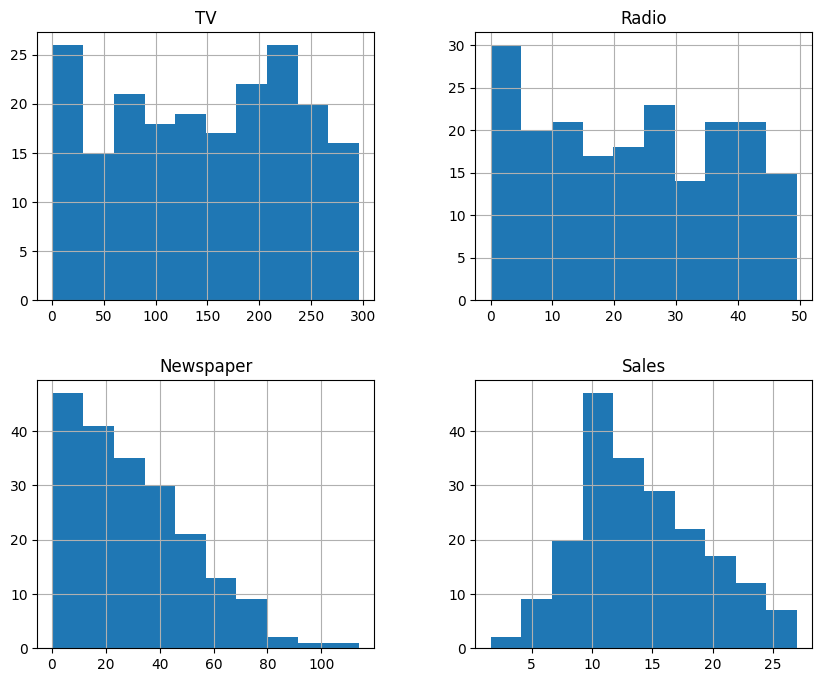

In [6]:
# 각 변수의 분포 확인
# 가로축은 값S
# 세로축은 수치
df.hist(figsize=(10, 8))
plt.show()


3. 데이터 분할
 - 전체 데이터를 학습 데이터와 테스트 데이터로 8:2 비율로 분할합니다. (scikit-learn의 train_test_split 함수 사용)


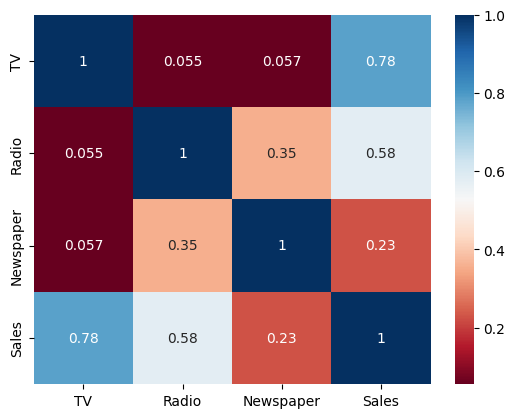

In [7]:
# 변수 간 상관관계 시각화
# 다중공산성 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu')
plt.show()

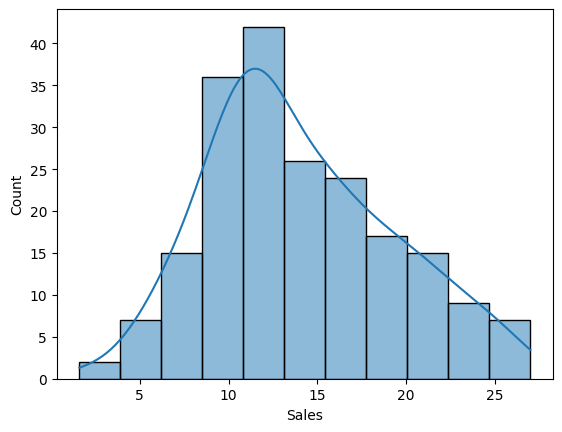

In [8]:
import warnings 
warnings.filterwarnings('ignore')
sns.histplot(x='Sales',data=df,kde=True)
plt.show()


4. 모델 학습
선형 회귀 모델을 학습 데이터로 학습시킵니다. (scikit-learn의 LinearRegression 모델 사용)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [10]:
scaled_data=pd.DataFrame(scaled_data,columns=df.columns)
scaled_data

,TV,Radio,Newspaper,Sales
0,0.969852,0.981522,1.778945,1.552053
1,-1.197376,1.082808,0.669579,-0.696046
2,-1.516155,1.528463,1.783549,-0.907406
3,0.052050,1.217855,1.286405,0.860330
4,0.394182,-0.841614,1.281802,-0.215683
...,...,...,...,...
195,-1.270941,-1.321031,-0.771217,-1.234053
196,-0.617035,-1.240003,-1.033598,-0.830548
197,0.349810,-0.942899,-1.111852,-0.234898
198,1.594565,1.265121,1.640850,2.205347


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']


3. 데이터 분할
 - 전체 데이터를 학습 데이터와 테스트 데이터로 8:2 비율로 분할합니다. (scikit-learn의 train_test_split 함수 사용)

4. 모델 학습
선형 회귀 모델을 학습 데이터로 학습시킵니다. (scikit-learn의 LinearRegression 모델 사용)

5. 예측
 - 테스트 데이터에 대한 판매량을 예측합니다.

6. 모델 평가
 - 테스트 데이터에 대한 R-squared (결정 계수) 값을 계산하여 모델 성능을 평가합니다. (scikit-learn의 r2_score 함수 사용)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
lr_model=LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Test R-squared: {r2}")

Test R-squared: 0.899438024100912


In [16]:
lr_model.score(X_train,y_train)

0.8957008271017818

In [17]:
y_pred=lr_model.predict(X_test)

In [18]:
r2_score(y_test,y_pred)

0.899438024100912

In [19]:
print(mean_squared_error(y_test,y_pred))

3.1740973539761033


In [20]:
y_pred

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

 

7. 새로운 데이터 예측
 - TV=200, Radio=50, Newspaper=30 일 때 판매량을 예측합니다.

8. 결과 출력
 - 테스트 데이터에 대한 R-squared 값을 출력합니다.
 - 새로운 데이터에 대한 예측 판매량을 출력합니다.

9. 시각화
 - 실제 판매량 vs 예측 판매량 산점도: 테스트 데이터의 실제 판매량과 예측 판매량을 산점도로 시각화합니다. x축은 실제 판매량, y축은 예측 판매량으로 설정하고, 제목과 축 레이블을 명확하게 표시합니다.
 - 각 독립변수와 판매량과의 관계 시각화: 각 독립 변수('TV', 'Radio', 'Newspaper')와 'Sales' 간의 산점도를 그리고, 회귀선을 추가하여 시각화합니다. 

In [21]:

new_data = [[200, 50, 30]]
new_pred = lr_model.predict(new_data)
print(f"새로운 데이터 예측 판매량: {new_pred[0]}")

새로운 데이터 예측 판매량: 21.467556973825737


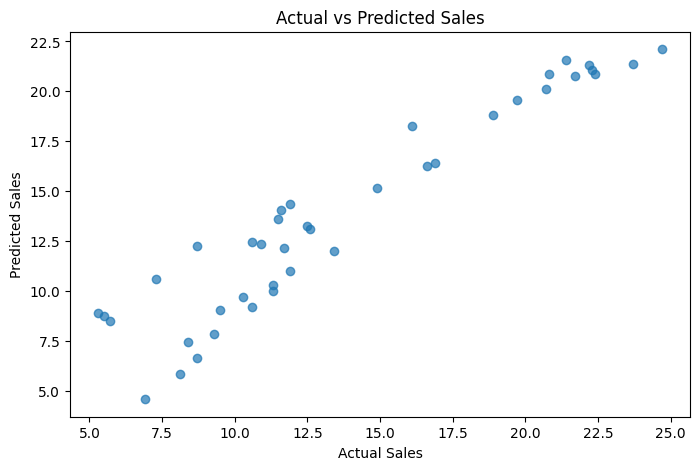

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

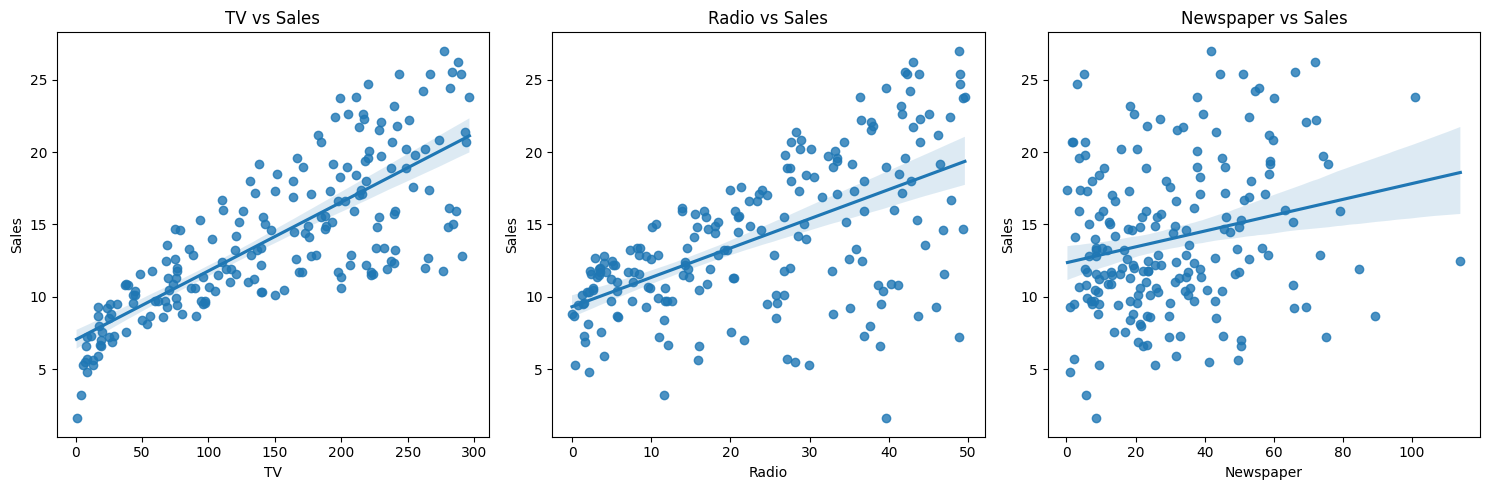

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(X.columns):
    sns.regplot(x=df[col], y=df['Sales'], ax=axes[i])
    axes[i].set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()